In [1]:
# 1. Import Required Libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

First Five Rows of Dataset
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst

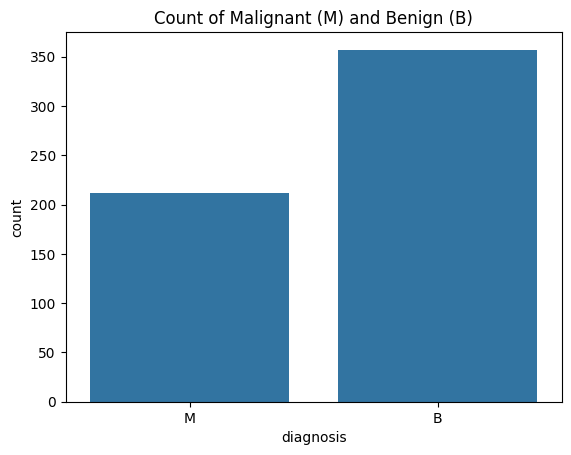

In [2]:
# 2. Data Loading and Exploration 

# Load dataset 
df = pd.read_csv("breast_ cancer.csv") 

# Display first five rows 
print("First Five Rows of Dataset") 
print(df.head())

# Dataset shape 
print("\nDataset Shape:") 
print(df.shape) 

# Column names 
print("\nColumn Names:") 
print(df.columns) 

# Check missing values 
print("\nMissing Values:") 
print(df.isnull().sum()) 

# Statistical summary 
print("\nStatistical Summary:") 
print(df.describe()) 

# Count of Malignant and Benign cases 
print("\nDiagnosis Count:") 
print(df['diagnosis'].value_counts()) 

# Visualization of diagnosis count 
sns.countplot(x='diagnosis', data=df) 
plt.title("Count of Malignant (M) and Benign (B)") 
plt.show()

In [4]:
# 3. Data Preprocessing 
# Encode target variable (M=1, B=0) 

df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0}) 

# Drop ID column if present 
if 'id' in df.columns: 
    df = df.drop('id', axis=1) 

# Separate features and target 
X = df.drop('diagnosis', axis=1) 
y = df['diagnosis'] 

# Feature Scaling 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

# Train Test Split (70-30) 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42) 

In [5]:
# 4. Implementation of KNN Algorithm  
# Initial K value 

k = 5 
knn = KNeighborsClassifier(n_neighbors=k)

# Train model 
knn.fit(X_train, y_train)

# Prediction 
y_pred = knn.predict(X_test)


Accuracy Score: 0.9590643274853801

Confusion Matrix:
[[105   3]
 [  4  59]]


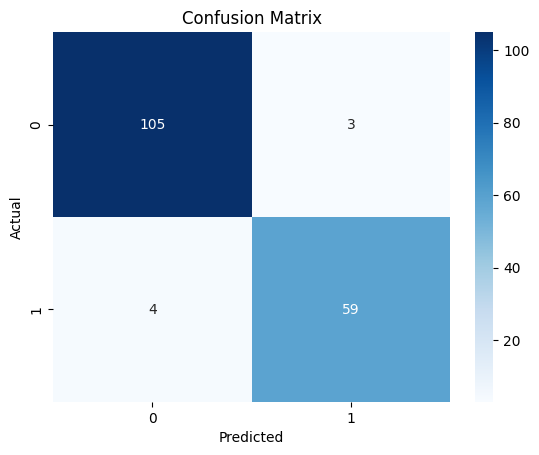


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       108
           1       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [6]:
# 5. Model Evaluation  
# Accuracy Score 

accuracy = accuracy_score(y_test, y_pred) 
print("\nAccuracy Score:", accuracy) 

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred) 
print("\nConfusion Matrix:") 
print(cm)

# Visualization of Confusion Matrix 
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d") 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show() 

# Precision, Recall, F1-score 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred))

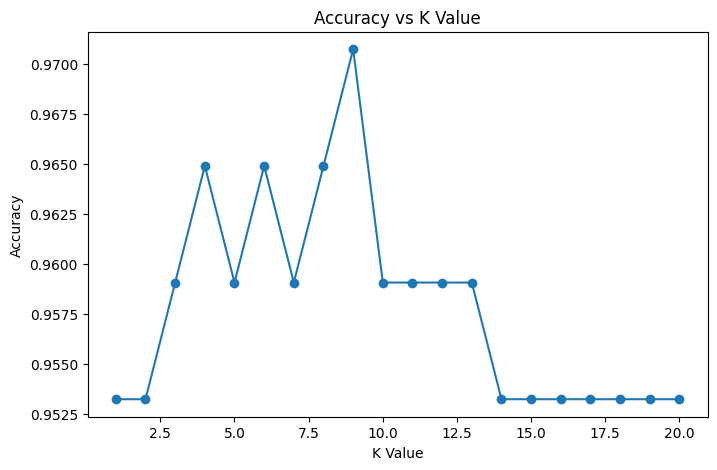


Optimal K Value: 9


In [8]:
# 6. Hyperparameter Tuning (Finding Best K) 

accuracy_list = [] 
for i in range(1,21): 
    knn = KNeighborsClassifier(n_neighbors=i) 
    knn.fit(X_train, y_train) 
    pred_i = knn.predict(X_test) 
    accuracy_list.append(accuracy_score(y_test, pred_i)) 

# Plot Accuracy vs K 
plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy_list, marker='o') 
plt.title("Accuracy vs K Value") 
plt.xlabel("K Value") 
plt.ylabel("Accuracy") 
plt.show() 

# Best K value 
best_k = accuracy_list.index(max(accuracy_list)) + 1 
print("\nOptimal K Value:", best_k)

In [9]:
# 7. Final Model with Optimal K 

knn_final = KNeighborsClassifier(n_neighbors=best_k) 
knn_final.fit(X_train, y_train) 
final_pred = knn_final.predict(X_test) 
final_accuracy = accuracy_score(y_test, final_pred) 
print("\nFinal Accuracy with Optimal K:", final_accuracy) 
print("\nFinal Confusion Matrix:") 
print(confusion_matrix(y_test, final_pred)) 
print("\nFinal Classification Report:") 
print(classification_report(y_test, final_pred))


Final Accuracy with Optimal K: 0.9707602339181286

Final Confusion Matrix:
[[106   2]
 [  3  60]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       108
           1       0.97      0.95      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

